In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import os
from scipy.signal import find_peaks
from scipy import constants
from lmfit.models import LinearModel
from lmfit import Model
from scipy.stats import pearsonr

## Campo Magnético

#### Funciones

In [5]:
def plot_B(data_path, n):
    df = pd.read_csv('data/' + data_path)
    B_all = df['B [G]']
    dB_all = df['dB [G]']
    B = df['B [G]'][:n]
    dB = df['dB [G]'][:n]
    I_all = df['I [A]']
    dI_all = df['dI [A]']
    I = df['I [A]'][:n]
    dI = df['dI [A]'][:n]

    modelo = LinearModel()
    result = modelo.fit(B, x=I, weights=1 / dB)
    x = np.linspace(I.min(), I.max(), 1000)
    m_val = result.params['slope'].value
    m_err = result.params['slope'].stderr
    b_val = result.params['intercept'].value
    b_err = result.params['intercept'].stderr
    sigma = result.eval_uncertainty(x=x, sigma=1)

   
    Bfit = m_val*x + b_val
    print(result.fit_report())

    fig, ax = plt.subplots(figsize= (9, 6), dpi=300)

    ax.errorbar(I, B, xerr = dI, yerr = dB, color='k', fmt = 's',label='Datos Experimantales', markersize =2, capsize = 0, zorder = 1)
    plt.plot(x, Bfit, color="blue",linewidth=1, label="Ajuste Lineal ($R$ = 0.9999)", zorder=2)

    plt.fill_between(
    x,
    Bfit - sigma,  
    Bfit + sigma,
    color="blue",
    alpha=0.15, 
    label="Desviación Estándar del Ajuste",
    zorder=2,
)

    texto_ecuacion = (
    f"$m = {m_val:.4f} \pm {m_err:.4f}$\n"
    f"$b = {b_val:.4f} \pm {b_err:.4f}$")

    propiedades_cuadro = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.95, 0.05, texto_ecuacion, 
            transform=ax.transAxes, # <-- Esto hace la magia
            fontsize=10, 
            bbox=propiedades_cuadro, 
            verticalalignment='bottom',
            horizontalalignment='right')

    

    ax.set_title(f'Campo Magnético del Electroimán con Núcleos de Hierro ' + '$B$', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Corriente $I$ [A]', fontsize=12)
    ax.set_ylabel('Campo Magnético $B$ [G]', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('plots/magnetic_field.png', bbox_inches='tight')
    plt.show()
    return m_val, b_val

[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 103
    # variables        = 2
    chi-square         = 1822.15205
    reduced chi-square = 18.0411094
    Akaike info crit   = 299.923587
    Bayesian info crit = 305.193045
    R-squared          = 0.99995578
[[Variables]]
    slope:      427.099997 +/- 0.28260994 (0.07%) (init = 1)
    intercept: -13.1084171 +/- 0.79782471 (6.09%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.8514


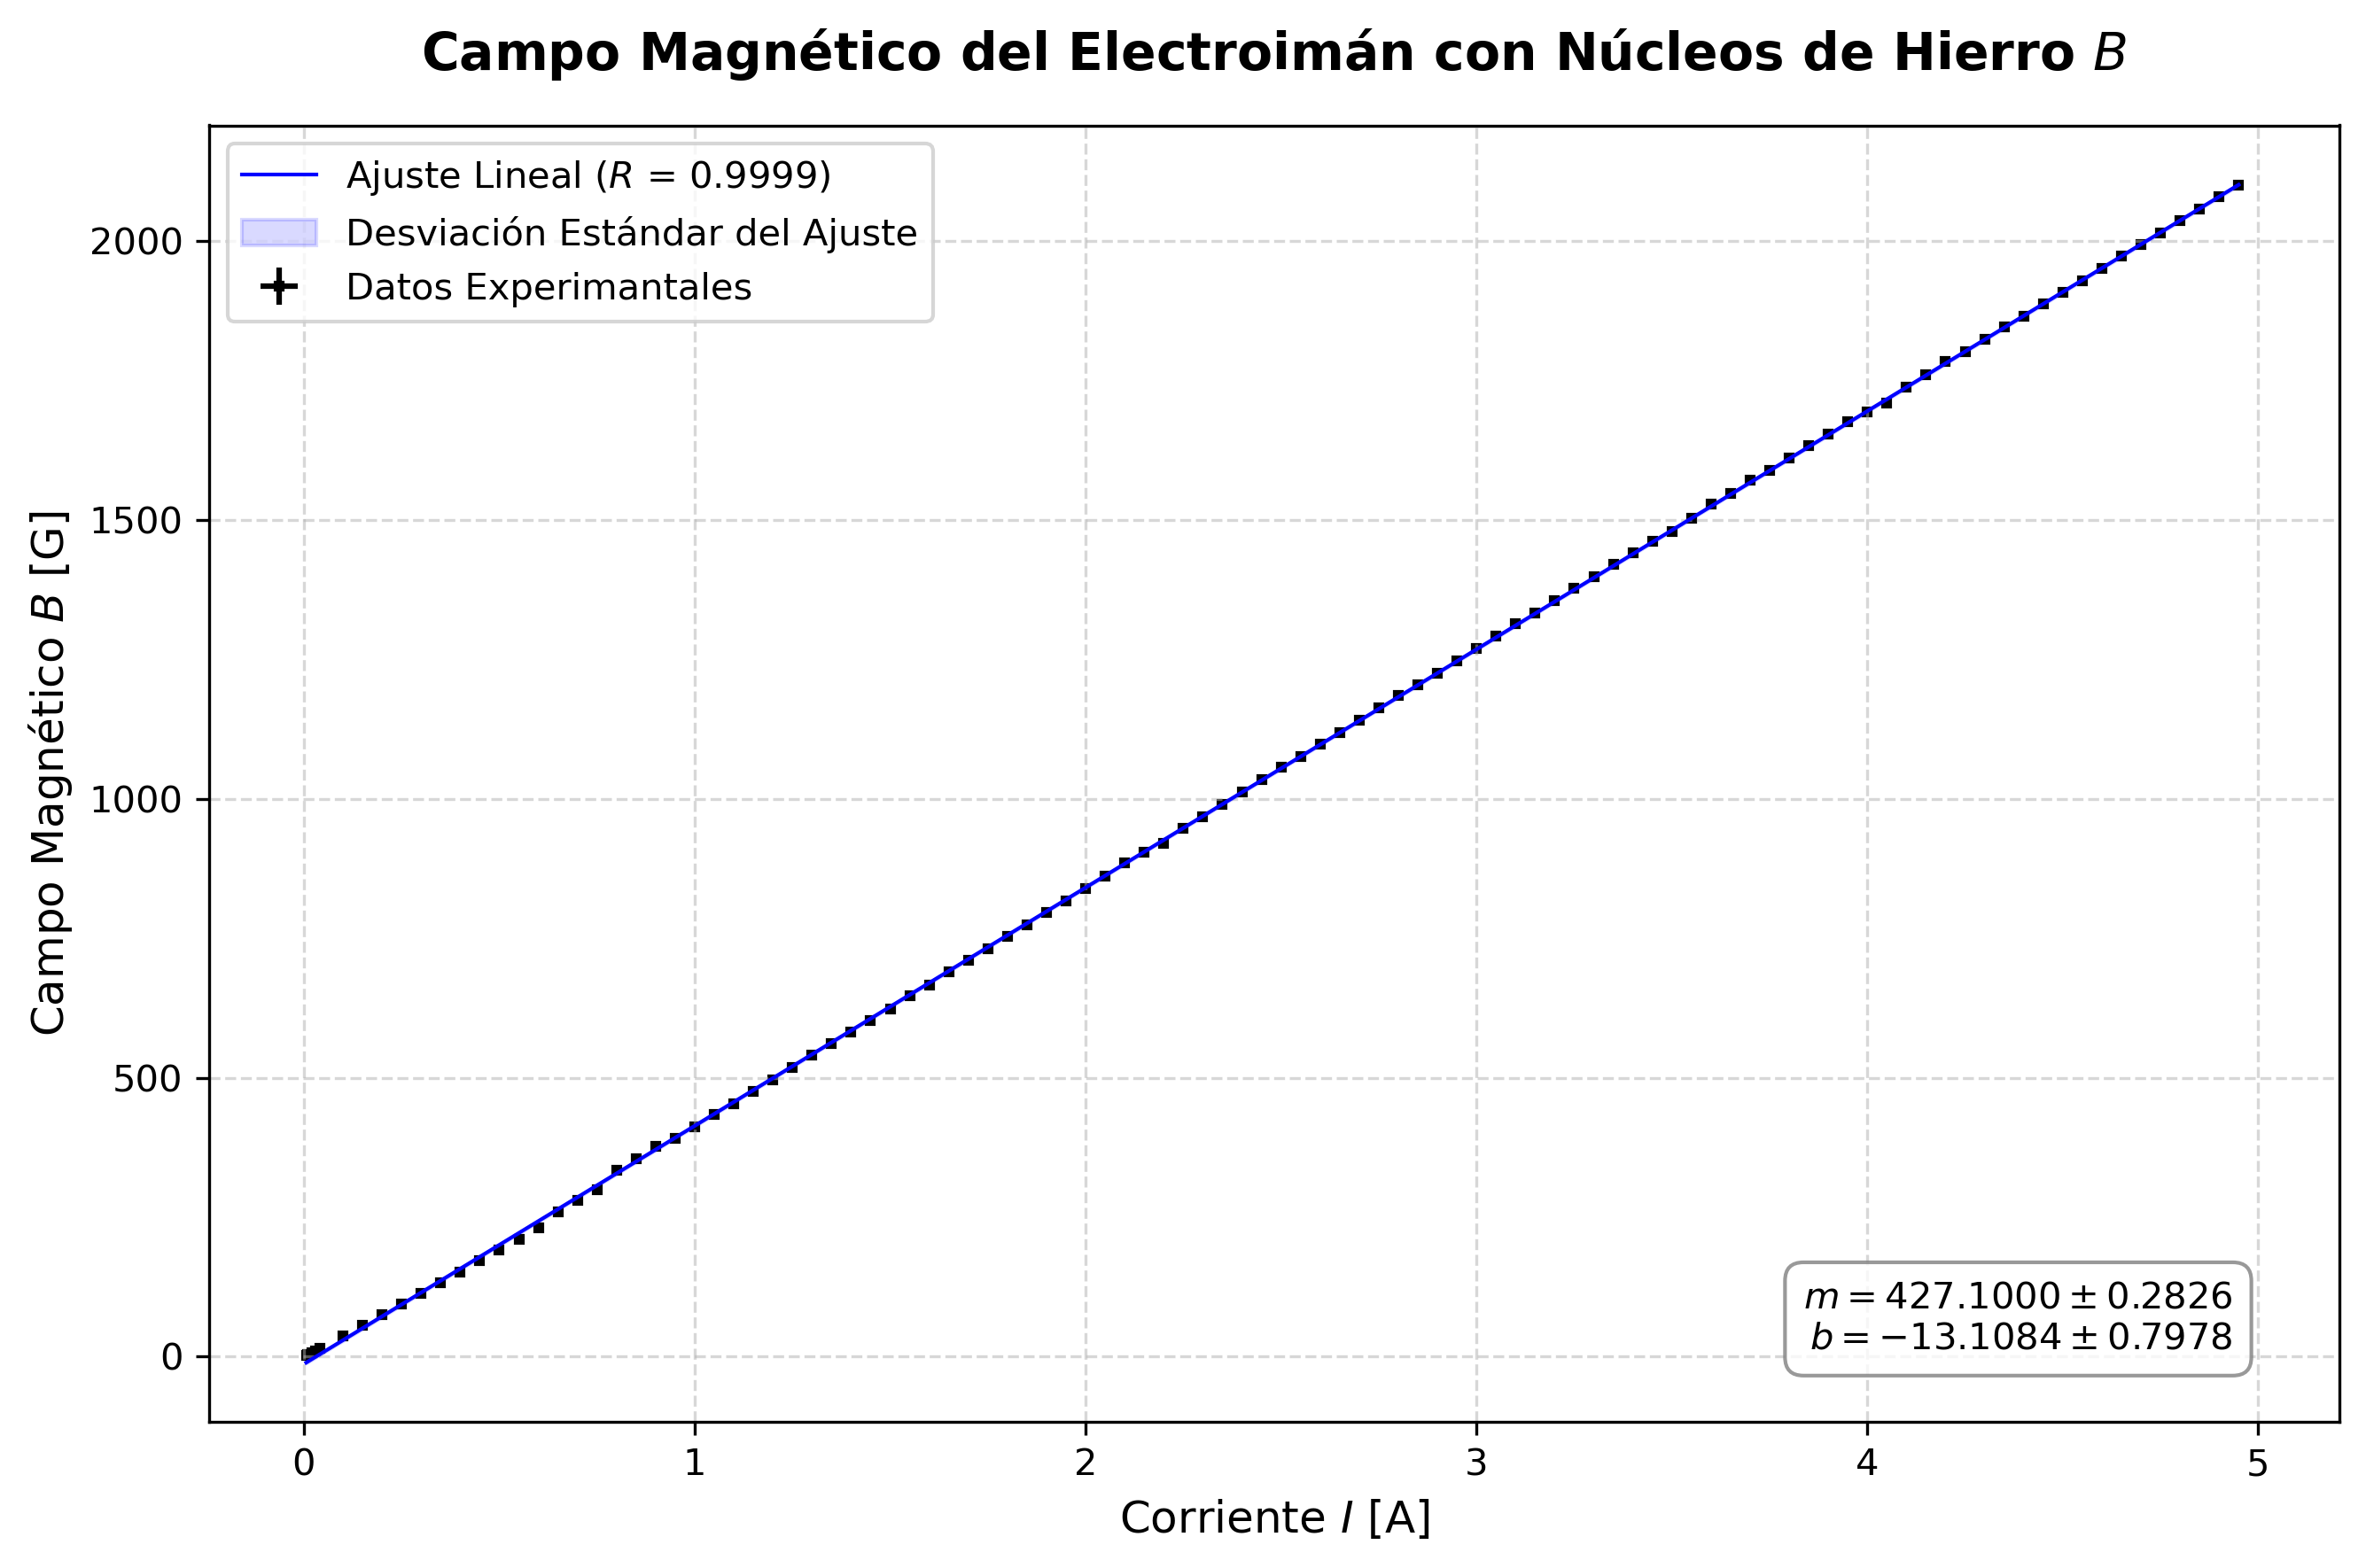

In [6]:
m , b = plot_B('magnetic_field_20_05_26.csv', n = 181)

## Efecto Faraday

### Método de Extinción

#### Funciones

In [29]:
def plot_vernet(data_path, crystal, slope, intercept, method):
    df = pd.read_csv('data/' +  data_path)

    df_cristal = df[df["Sample"] == crystal]

    if df_cristal.empty:
        print(f"Error: No se encontraron datos para el cristal '{cristal_buscado}'")
        return
    
    longitudes_unicas = df_cristal["L [cm]"].unique()

    lista_L = []
    lista_m = []
    lista_b = []
    lista_V = []
    lista_r2 = []

    plt.figure(figsize=(9, 6))
    lista_V = []
    colores = colormaps.get_cmap("tab10")( len(longitudes_unicas))
    
    for i, longitud in enumerate(longitudes_unicas):
        df_longitud = df_cristal[df_cristal["L [cm]"] == longitud]
        I = df_longitud["I [A]"].values
        dI = df_longitud["dI [A]"].values
        B = (slope*I + intercept)*1e-4
        dB = (slope*dI)*1e-4
        theta = df_longitud["t [deg]"].values
        dtheta = df_longitud["dt [deg]"].values

        modelo = LinearModel()
        resultado = modelo.fit(theta, x=B, weights = 1/dtheta)

        m = resultado.params["slope"].value
        b = resultado.params["intercept"].value

        m_val = resultado.params['slope'].value
        m_err = resultado.params['slope'].stderr
        b_val = resultado.params['intercept'].value
        b_err = resultado.params['intercept'].stderr

        B_recta = np.linspace(B.min(), B.max(), 500)
        theta_recta = m * B_recta + b
        sigma = resultado.eval_uncertainty(x=B_recta, sigma=1)

        color_actual = tuple(plt.cm.tab10(i % 10))
        plt.errorbar(B, theta, xerr = dB, yerr = dtheta, fmt="s", color=color_actual, ms=4, alpha=0.7, label=f"Datos L = {longitud} cm", zorder=2)
        plt.plot(B_recta, theta_recta, color=color_actual, linestyle="--", linewidth=1, 
                 label=f"Ajuste L={longitud} cm (m= {m_val:.2f} $\pm$ {m_err:.2f}, b= {b_val:.2f} $\pm$ {b_err:.2f})",zorder=3)

        m_actual = resultado.params["slope"].value
        b_actual = resultado.params["intercept"].value
        V_actual = (m_actual / longitud)*(np.pi*100/180)
        r2_actual = resultado.rsquared

        lista_L.append(longitud)
        lista_m.append(m_actual)
        lista_b.append(b_actual)
        lista_V.append(V_actual)
        lista_r2.append(r2_actual)

    plt.title(f"Método de Extinción - Ferrofluido {crystal}",fontsize=14, fontweight="bold")
    plt.xlabel("Campo Magnético $B$ [T]", fontsize=12)
    plt.ylabel(r"Ángulo de Rotación $\theta$ [deg]", fontsize=12)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left", fontsize=10)

    plt.tight_layout()
    plt.savefig(f'plots/faraday_effect_{crystal}_{method}.png', bbox_inches='tight')
    plt.show()

    arr_V = np.array(lista_V)

    V_promedio = np.mean(arr_V)
    V_desviacion = np.std(arr_V, ddof=1)

    datos_resumen = {
    "Longitud [cm]": lista_L,
    "Pendiente m": lista_m,
    "Ordenada b": lista_b,
    "V [rad*T⁻¹*m⁻¹]": lista_V,
    "Correlación (R²)": lista_r2}

    df_resumen = pd.DataFrame(datos_resumen)

    print("\n" + "=" * 80)
    print(f"TABLA RESUMEN DE RESULTADOS: FERROFLUIDO {crystal}")
    print("=" * 80)
    print(df_resumen.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
    print("=" * 80 + "\n")
    print(f"Constante de Verdet (V) promedio para muestra {crystal}: ({V_promedio:.4f}  \u00b1 {V_desviacion:.4f}) rad T\u207B\u00B9 m\u207B\u00B9")
    

#### Método de Extinción

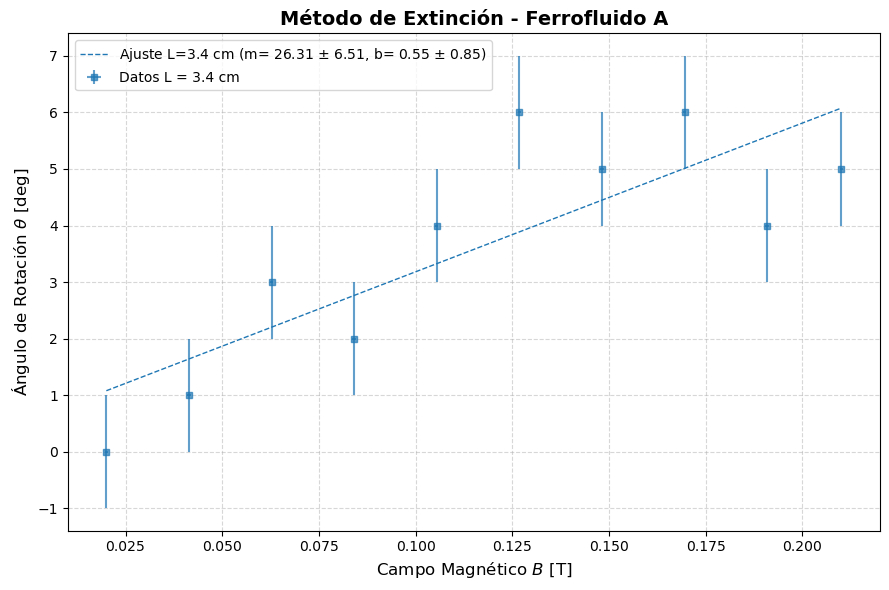


TABLA RESUMEN DE RESULTADOS: FERROFLUIDO A
 Longitud [cm]  Pendiente m  Ordenada b  V [rad*T⁻¹*m⁻¹]  Correlación (R²)
       3.40000     26.31458     0.54940         13.50812           0.67112

Constante de Verdet (V) promedio para muestra A: (13.5081  ± nan) rad T⁻¹ m⁻¹


C:\Users\Personal\anaconda3\Lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Personal\anaconda3\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [30]:
plot_vernet("nanofluid_25_05_26.csv", "A", slope=m, intercept=b, method = 'ext')

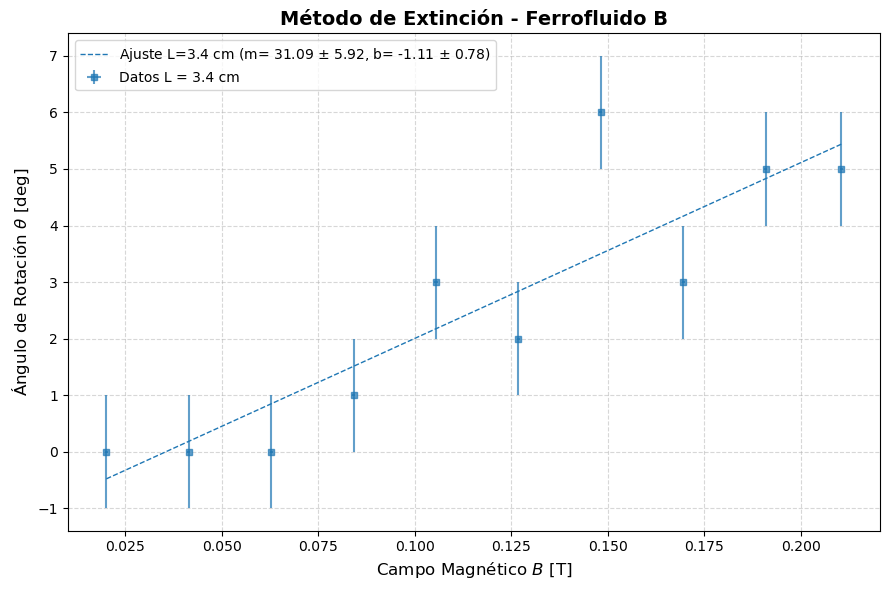


TABLA RESUMEN DE RESULTADOS: FERROFLUIDO B
 Longitud [cm]  Pendiente m  Ordenada b  V [rad*T⁻¹*m⁻¹]  Correlación (R²)
       3.40000     31.09013    -1.10555         15.95956           0.77530

Constante de Verdet (V) promedio para muestra B: (15.9596  ± nan) rad T⁻¹ m⁻¹


C:\Users\Personal\anaconda3\Lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Personal\anaconda3\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [31]:
plot_vernet("nanofluid_25_05_26.csv", "B", slope=m, intercept=b, method = 'ext')